In [3]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.ndimage import label
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi
from skimage.segmentation import find_boundaries
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import curve_fit
from scipy.ndimage import map_coordinates
import seaborn as sns
from scipy.ndimage import maximum_filter, label

In [4]:
#Defining all the required functions

#Fourier Transform Functions
def partial_x_fft(f, dx):
    nx, ny = f.shape
    kx = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    f_fft = np.fft.fft(f, axis=0)
    df_fft = 1j * kx[:, None] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=0))

def partial_y_fft(f, dy):
    nx, ny = f.shape
    ky = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
    f_fft = np.fft.fft(f, axis=1)
    df_fft = 1j * ky[None, :] * f_fft
    return np.real(np.fft.ifft(df_fft, axis=1))

#Defining constants
dx = 0.0625
dy = 0.0625

In [23]:
#Lets Computer J_total

# 1. Read the HDF5 file
File_Bx = '/DATA/DEVESH/TestDevesh/Bx_ApJ_t31.h5'  # Replace with your file path
File_By = '/DATA/DEVESH/TestDevesh/By_ApJ_t31.h5'  # Replace with your file path
File_Bz = '/DATA/DEVESH/TestDevesh/Bz_ApJ_t31.h5'  # Replace with your file path

sigma = 5.0  # Adjust blur strength

with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
    data_Bx = fBx['DS1'][:].T
    data_By = fBy['DS1'][:].T
    data_Bz = fBz['DS1'][:].T
    data_Bx_filtered = ndi.gaussian_filter(data_Bx,sigma=sigma)
    data_By_filtered = ndi.gaussian_filter(data_By,sigma=sigma)
    data_Bz_filtered = ndi.gaussian_filter(data_Bz,sigma=sigma)
    data_Jx = partial_y_fft(data_Bz_filtered,dx)
    data_Jy = -partial_x_fft(data_Bz_filtered,dy)
    data_Jz = partial_x_fft(data_By_filtered,dy)-partial_y_fft(data_Bx_filtered,dx)

J_squared = data_Jx**2 + data_Jy**2 + data_Jz**2
J_squared = ndi.gaussian_filter(J_squared, sigma=sigma)


#Different Strategies for Threshold
#Strategy 1: Pick top 10% of the features
threshold = np.quantile(J_squared, 0.95)

#Strategy 2: 
# N = 3
# J_squared_rms = np.sqrt(np.mean(J_squared**2))
# threshold = np.mean(J_squared) + N*J_squared_rms

print("Threshold:", threshold)

binary_mask = np.abs(J_squared) > threshold


# MORPHOLOGICAL SMOOTHING
struct = morphology.disk(5)

smoothed_mask = morphology.binary_opening(binary_mask, struct)
smoothed_mask = morphology.binary_closing(smoothed_mask, struct)
smoothed_mask = smoothed_mask.astype(int)

#Remove small areas
min_area = 300 # choose based on eye balling
cleaned_mask = morphology.remove_small_objects(smoothed_mask.astype(bool), min_size=min_area).astype(int)

Threshold: 0.012595863675002247


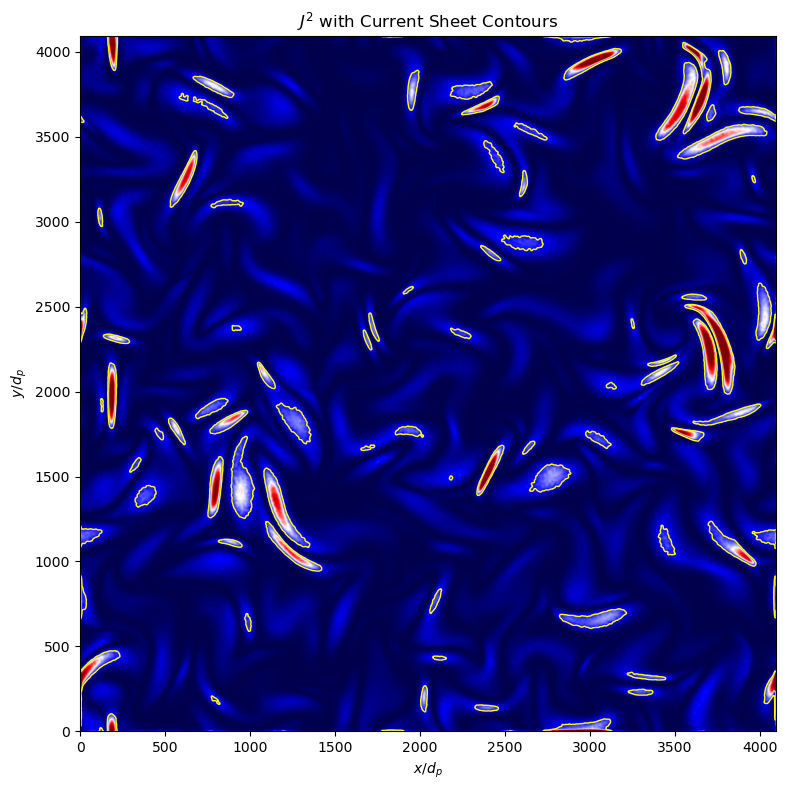

In [24]:
#Plot current sheets over the base J_squared field

plt.figure(figsize=(10, 8))

# Base field
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05)
# plt.imshow(J_squared.T, cmap='seismic', origin='lower')

# Add current-sheet boundaries
plt.contour(cleaned_mask.T, levels=[0.5], colors='yellow', linewidths=1)

plt.title(r'$J^{2}$ with Current Sheet Contours')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')
plt.tight_layout()
plt.savefig("J2_NR_with_CS_contours_GB.png", dpi=300)
plt.show()

In [25]:
#FIND MAXIMUM IN EACH CONNECTED REGION

labeled_mask, num_features = label(cleaned_mask)
print("Regions found:", num_features)

max_coords = []
max_values = []

for i in range(1, num_features + 1):
    region_mask = (labeled_mask == i)
    region_vals = J_squared[region_mask]

    if region_vals.size == 0:
        continue

    # Extreme value (max magnitude)
    max_pos = np.argmax(np.abs(region_vals))
    extreme_value = region_vals[max_pos]
    max_values.append(extreme_value)

    # Convert index → coordinates
    xs, ys = np.where(region_mask)
    max_coords.append((xs[max_pos], ys[max_pos]))

Regions found: 88


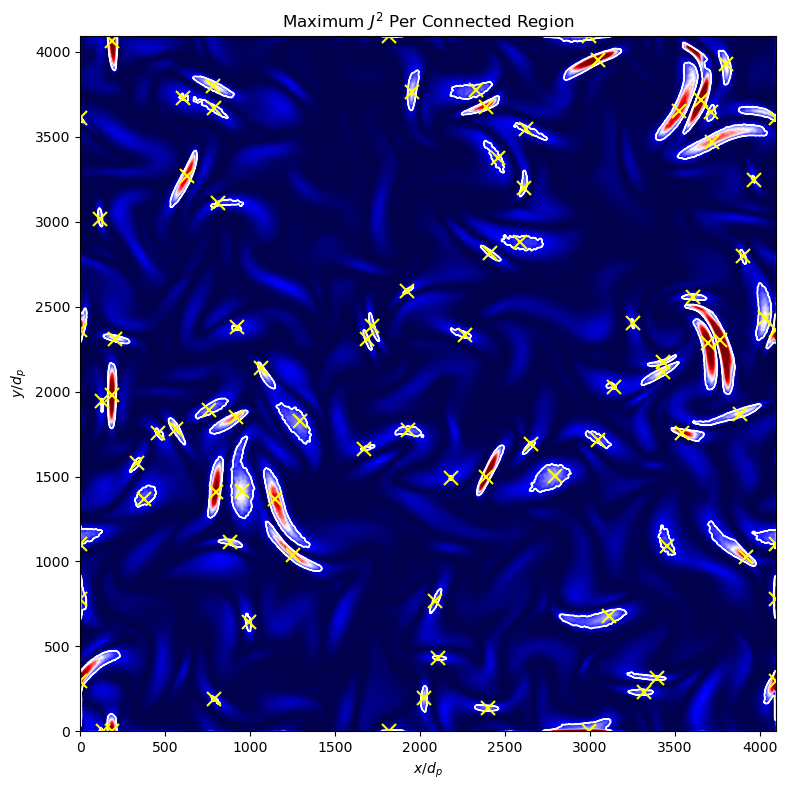

In [26]:
# PLOT ORIGINAL FIELD + MASK + MAXIMUM POINTS

plt.figure(figsize=(10, 8))

# --- Base field ---
plt.imshow(J_squared.T, cmap='seismic', origin='lower', vmax=0.05)

# --- Boundaries of CSs---
boundaries = find_boundaries(labeled_mask)
plt.contour(boundaries.T, levels=[0.5], colors='white', linewidths=1)

# --- Overlay maxima as yellow crosses ---
for x, y in max_coords:
    plt.plot(x, y, marker='x', markersize=10, markeredgewidth=1.5, color='yellow')

plt.title(r'Maximum $J^{2}$ Per Connected Region')
plt.xlabel(r'$x/d_p$')
plt.ylabel(r'$y/d_p$')

plt.tight_layout()
plt.savefig("J2_NR_maxima_overlay_GB.png", dpi=300)
plt.show()

Number of connected regions: 88
Found 88 sheets
Mean thickness = 50.074 pixels
Median thickness = 46.085 pixels
Min thickness = 12.649 px, Max = 132.966 px


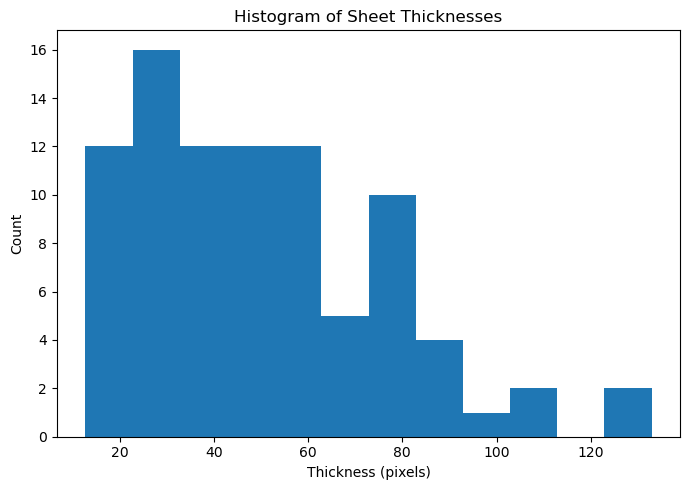

In [27]:
# Method 1 for Thickness Computation: Using the internal function for diameter of largest inscribed circle

#1. Labelling each connected region

labeled_mask = measure.label(cleaned_mask, connectivity=2)
num_regions = labeled_mask.max()
print("Number of connected regions:", num_regions)

#2. Compute thicknesses

thicknesses_m1 = []

for label_id in range(1, num_regions + 1):

    region = (labeled_mask == label_id)

    # Euclidean distance transform INSIDE the region
    dist = ndi.distance_transform_edt(region)

    # Full sheet thickness = diameter of largest inscribed circle
    thickness = 2 * dist.max()

    thicknesses_m1.append(thickness)

# 3. Some Central Measures of the statistics

print(f"Found {len(thicknesses_m1)} sheets")
print(f"Mean thickness = {np.mean(thicknesses_m1):.3f} pixels")
print(f"Median thickness = {np.median(thicknesses_m1):.3f} pixels")
print(f"Min thickness = {np.min(thicknesses_m1):.3f} px, Max = {np.max(thicknesses_m1):.3f} px")

# 4. Histogram of thicknesses

plt.figure(figsize=(7,5))
plt.hist(thicknesses_m1, bins=12)
plt.xlabel("Thickness (pixels)")
plt.ylabel("Count")
plt.title("Histogram of Sheet Thicknesses")
plt.tight_layout()
plt.savefig("J2_NR_M1_Beta_GB.png", dpi=300)
plt.show()    

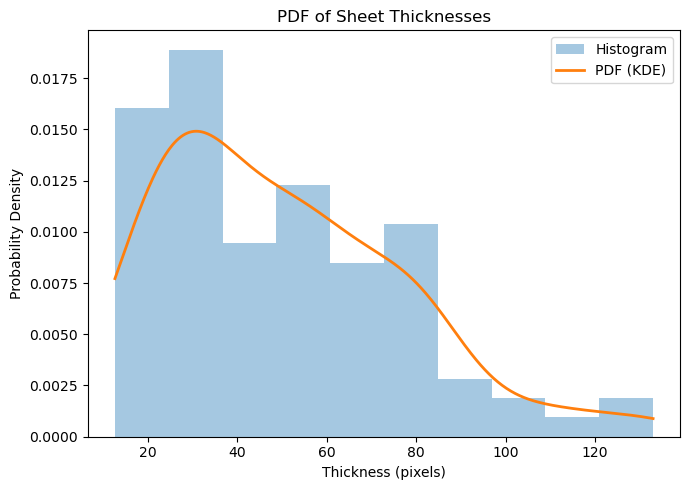

In [30]:
#Plot a smooth PDF of the same data
plt.figure(figsize=(7,5))

# Histogram (normalized)
plt.hist(thicknesses_m1, bins=10, density=True, alpha=0.4, label="Histogram")

# KDE curve
kde = gaussian_kde(thicknesses_m1)
xs = np.linspace(min(thicknesses_m1), max(thicknesses_m1), 500)
plt.plot(xs, kde(xs), linewidth=2, label="PDF (KDE)")
plt.xlabel("Thickness (pixels)")
plt.ylabel("Probability Density")
plt.title("PDF of Sheet Thicknesses")
plt.legend()
plt.tight_layout()
plt.savefig("J2_M1_GB.png", dpi=300)
plt.show()